In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl


In [4]:
import pandas as pd

# Load dataset
df = pd.read_pickle('/kaggle/input/datasets/qingyi/wm811k-wafer-map/LSWMD.pkl')

print("Shape:", df.shape)
df.head()

Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [13]:
print(df.columns)

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [12]:
df['failureType'].head(100)

0     [[none]]
1     [[none]]
2     [[none]]
3     [[none]]
4     [[none]]
        ...   
95    [[none]]
96    [[none]]
97    [[none]]
98    [[none]]
99    [[none]]
Name: failureType, Length: 100, dtype: object

In [3]:
def extract_label(x):
    try:
        return x[0][0]
    except:
        return None

df['failureType'] = df['failureType'].apply(extract_label)

In [4]:
df['failureType'].value_counts()

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [5]:
df_none = df[df['failureType'] == 'none'].sample(10000, random_state=42)
df_defect = df[df['failureType'] != 'none']

df_balanced = pd.concat([df_none, df_defect])

print(df_balanced['failureType'].value_counts())

failureType
none         10000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64


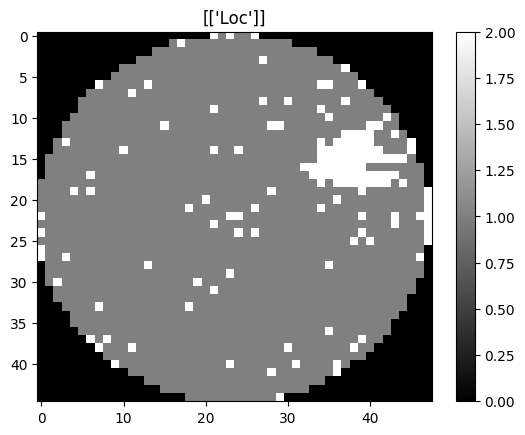

In [4]:
import matplotlib.pyplot as plt

sample = df.iloc[0]['waferMap']

plt.imshow(sample, cmap='gray')
plt.title(df.iloc[0]['failureType'])
plt.colorbar()
plt.show()

In [6]:
df = df[df['failureType'] != 'none']
df = df[df['failureType'].notnull()]

print("After cleaning:", df.shape)

After cleaning: (0, 6)


In [22]:
df_sample = df_balanced.sample(30000, random_state=42)

In [24]:
import numpy as np

X = df_sample['waferMap'].apply(lambda x: np.array(x)).values
y = df_sample['failureType'].values

print(len(X), len(y))

30000 30000


In [25]:
import cv2

def resize_map(wm, size=(16, 16)):
    return cv2.resize(wm.astype(np.float32), size)

X_resized = np.array([resize_map(w) for w in X])

print(X_resized.shape)

(30000, 16, 16)


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none') None]


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_flat = X_resized.reshape(X_resized.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_encoded, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1
)
model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9635
Test Accuracy: 0.9565


In [28]:
import joblib

joblib.dump(model, "wafer_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [31]:
df_balanced.to_csv("wafer_data.csv", index=False)

import joblib
joblib.dump(model, "wafer_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [34]:
import zipfile

with zipfile.ZipFile('wafer_data.zip', 'w') as z:
    z.write('wafer_data.csv')

In [35]:
df_balanced.sample(20000).to_csv("wafer_small.csv", index=False)

In [6]:
# Save REAL data (not CSV)
import pickle

with open("clean_data.pkl", "wb") as f:
    pickle.dump(df[['waferMap', 'failureType']], f)